# Figure 10 — The concordance field: PINN + HGP, and the Gaia tie

The residual astrometric field between Rubin/NISP and Euclid VIS is a real, coherent,
degree-scale MEASUREMENT (not a correction). Two independent solvers agree; HGP gives a
hierarchical decomposition; and the field is externally anchored to Gaia (PM-self-calibrated).
Top: NISP J concordance field from PINN and from HGP (they agree). Bottom-left: HGP
hierarchical decomposition (common / instrument-group / per-band residual RMS). Bottom-right:
Gaia self-calibration — the propagation epoch is measured by nulling the residual-vs-PM slope.

In [1]:
from pathlib import Path
import numpy as np, json
from astropy.io import fits
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root(); OUT=REPO/'paper'/'figures'/'fig10_concordance_field.png'
FD=REPO/'models/checkpoints/latent_position_q1_vissep'
PINN=FD/'concordance_pinn_q1_vissep_raw.fits'; HGP=FD/'hgp_q1_vissep_raw_supertight.fits'
HGPH=FD/'hgp_q1_vissep_headresid_supertight.fits'
HGPJSON=json.load(open(str(HGP)+'.json'))
GAIA=json.load(open(REPO/'io/_nb09_outputs/gaia_selfcal_curve.json'))
BAND='NISP_J'; COV_MASK_ARCSEC=45.0
print('field products:', PINN.name, HGP.name)


field products: concordance_pinn_q1_vissep_raw.fits hgp_q1_vissep_raw_supertight.fits


saved paper/figures/fig10_concordance_field.png


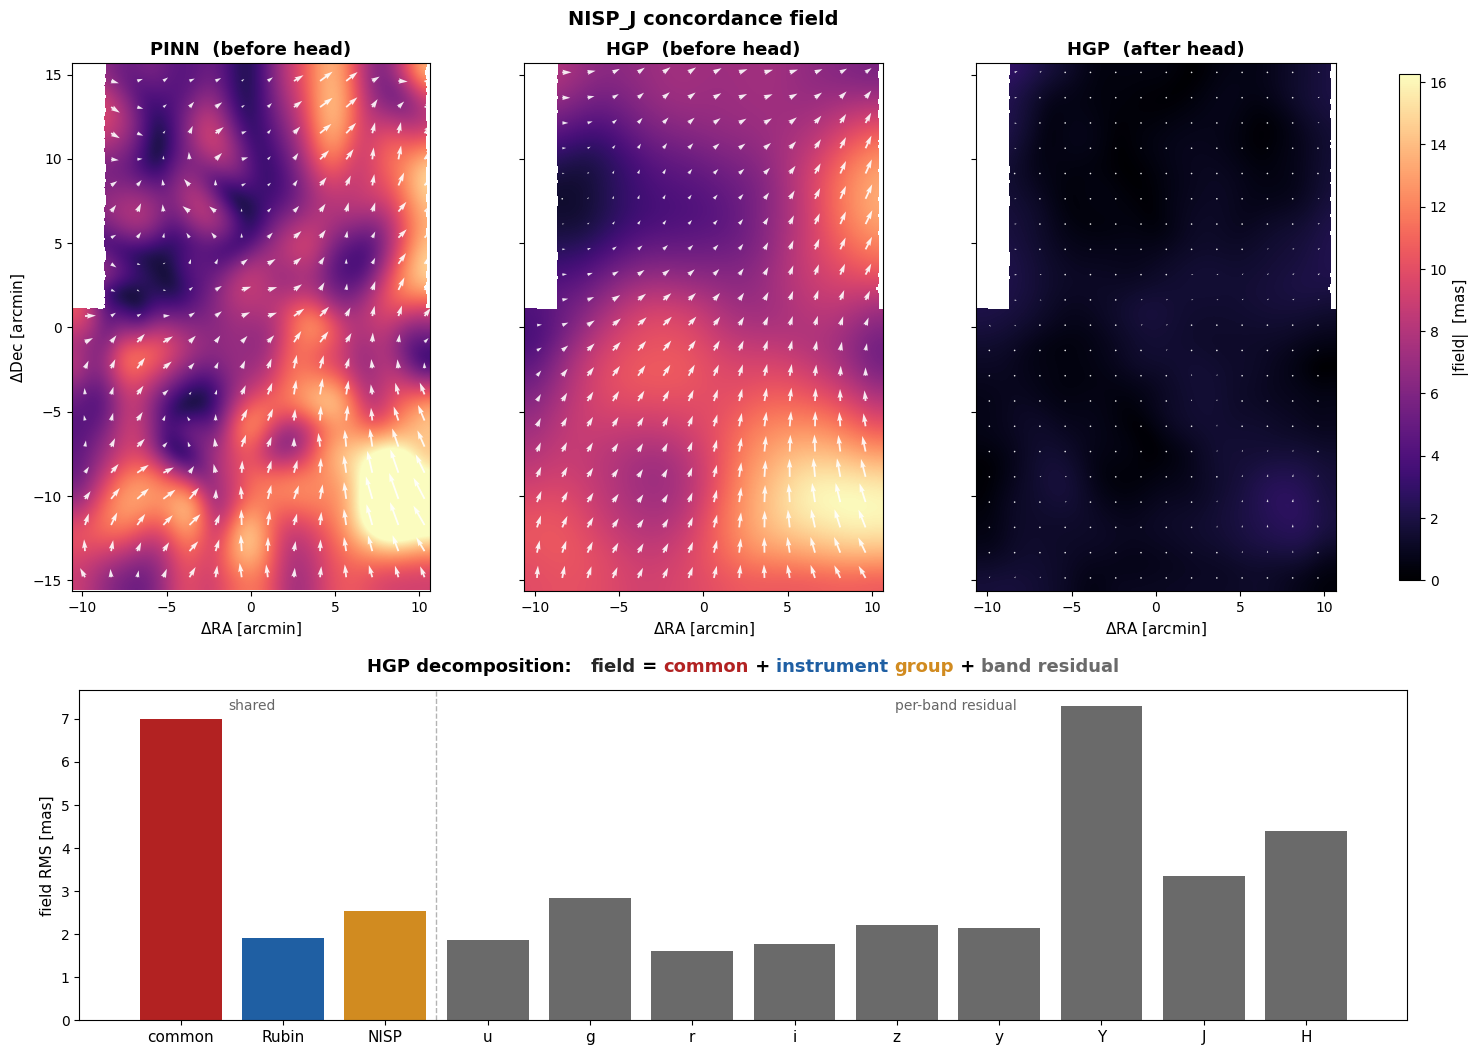

In [2]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
SMOOTH_ARCSEC=60.0

def nan_smooth(a,sig_px):
    m=np.isfinite(a).astype(float); a0=np.where(np.isfinite(a),a,0.0)
    num=gaussian_filter(a0*m,sig_px); den=gaussian_filter(m,sig_px)
    out=np.where(den>0.05,num/np.maximum(den,1e-6),np.nan)
    return np.where(m>0,out,np.nan)

def load_field(path, band):
    h=fits.open(path)
    dra=np.asarray(h[f'{band}.DRA'].data)*1000.0; dde=np.asarray(h[f'{band}.DDE'].data)*1000.0
    cov=np.asarray(h['COVERAGE'].data)
    cd=abs(float(h[f'{band}.DRA'].header.get('CDELT1',1/3600.)))*3600.0
    h.close()
    mask=cov>COV_MASK_ARCSEC
    dra=np.where(mask,np.nan,dra); dde=np.where(mask,np.nan,dde)
    sig=SMOOTH_ARCSEC/cd; dra=nan_smooth(dra,sig); dde=nan_smooth(dde,sig)
    mag=np.hypot(dra,dde); H,W=mag.shape
    ext=[-W*cd/120.0, W*cd/120.0, -H*cd/120.0, H*cd/120.0]
    return dra,dde,mag,ext

def draw_field(ax,dra,dde,mag,ext,title,vmax,ylabel=False):
    im=ax.imshow(mag,origin='lower',extent=ext,cmap='magma',vmin=0,vmax=vmax,aspect='equal')
    H,W=mag.shape; step=max(H,W)//20
    ys=np.arange(step//2,H,step); xs=np.arange(step//2,W,step); X,Y=np.meshgrid(xs,ys)
    xa=ext[0]+(X+0.5)/W*(ext[1]-ext[0]); ya=ext[2]+(Y+0.5)/H*(ext[3]-ext[2])
    ax.quiver(xa,ya,dra[Y,X],dde[Y,X],color='white',scale=vmax*18,width=0.005,alpha=0.9)
    ax.set_title(title,fontsize=13,fontweight='bold'); ax.set_xlabel('$\\Delta$RA [arcmin]',fontsize=11)
    if ylabel: ax.set_ylabel('$\\Delta$Dec [arcmin]',fontsize=11)
    else: ax.tick_params(labelleft=False)
    return im

fig=plt.figure(figsize=(16,11))
gtop=fig.add_gridspec(1,3,left=0.06,right=0.90,top=0.94,bottom=0.46,wspace=0.03)
pr=load_field(PINN,BAND); hr=load_field(HGP,BAND); hh=load_field(HGPH,BAND)
vmax=np.nanpercentile(np.concatenate([pr[2][np.isfinite(pr[2])],hr[2][np.isfinite(hr[2])]]),97)
a0=fig.add_subplot(gtop[0,0]); a1=fig.add_subplot(gtop[0,1],sharey=a0); a2=fig.add_subplot(gtop[0,2],sharey=a0)
draw_field(a0,*pr,'PINN  (before head)',vmax,ylabel=True)
draw_field(a1,*hr,'HGP  (before head)',vmax)
im=draw_field(a2,*hh,'HGP  (after head)',vmax)
cax=fig.add_axes([0.915,0.47,0.013,0.46]); cb=fig.colorbar(im,cax=cax); cb.set_label('|field|  [mas]',fontsize=11)
fig.text(0.48,0.975,f'{BAND} concordance field',ha='center',fontsize=14,fontweight='bold')

# bottom: HGP hierarchical decomposition (full width)
axC=fig.add_axes([0.09,0.07,0.83,0.30])
comp=HGPJSON['output']['components']
hier=[('COMMON','common','#b22222'),('GROUP_RUBIN','Rubin','#1f5fa3'),('GROUP_NISP','NISP','#d18b20')]
bands=[('BAND_U','u'),('BAND_G','g'),('BAND_R','r'),('BAND_I','i'),('BAND_Z','z'),('BAND_Y','y'),('BAND_NISP_Y','Y'),('BAND_NISP_J','J'),('BAND_NISP_H','H')]
labels=[h[1] for h in hier]+[b[1] for b in bands]
vals=[comp[h[0]]['field_rms_mas'] for h in hier]+[comp[b[0]]['field_rms_mas'] for b in bands]
cols=[h[2] for h in hier]+['#6a6a6a']*len(bands)
axC.bar(range(len(vals)),vals,color=cols)
axC.set_xticks(range(len(labels))); axC.set_xticklabels(labels,fontsize=11)
axC.axvline(2.5,color='0.7',ls='--',lw=1)
axC.text(0.13,0.94,'shared',transform=axC.transAxes,ha='center',fontsize=10,color='0.4')
axC.text(0.66,0.94,'per-band residual',transform=axC.transAxes,ha='center',fontsize=10,color='0.4')
axC.set_ylabel('field RMS [mas]',fontsize=11)
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
pieces=[('HGP decomposition:   ','k'),('field','0.15'),(' = ','k'),('common','#b22222'),
        (' + ','k'),('instrument ','#1f5fa3'),('group','#d18b20'),(' + ','k'),('band residual','#6a6a6a')]
tas=[TextArea(t,textprops=dict(color=cc,fontsize=13,fontweight='bold')) for t,cc in pieces]
ab=AnnotationBbox(HPacker(children=tas,align='center',pad=0,sep=0),(0.5,1.07),
                  xycoords='axes fraction',frameon=False,box_alignment=(0.5,0.5))
axC.add_artist(ab)

fig.savefig(OUT,dpi=200,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()
